# 04 — CNN Training (Transportation vs Conversation)

Trains a 3-block CNN on mel spectrograms for binary classification.

**Architecture:** Conv2D×3 → BatchNorm → MaxPool → GlobalAveragePooling → Dense(128) → Dense(1, sigmoid)

**Input:** (128 mel bands × 173 time frames × 1 channel)
**Output:** P(conversation) — threshold 0.5 for label

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

from src.cnn_classifier import CNNClassifier

SPLIT_DIR  = '../data/processed/train_test_split'
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODELS_DIR, 'cnn_model_v2.keras')

## 1. Load training data

In [2]:
X_train = np.load(os.path.join(SPLIT_DIR, 'X_train.npy'))
X_test  = np.load(os.path.join(SPLIT_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(SPLIT_DIR, 'y_train.npy'))
y_test  = np.load(os.path.join(SPLIT_DIR, 'y_test.npy'))

# Add channel dimension for CNN: (N, 128, 173) → (N, 128, 173, 1)
X_train = X_train[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f'X_train : {X_train.shape}  y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}   y_test  : {y_test.shape}')
print(f'Train — Transport: {(y_train==0).sum()}  Conversation: {(y_train==1).sum()}')
print(f'Test  — Transport: {(y_test==0).sum()}   Conversation: {(y_test==1).sum()}')

X_train : (4076, 128, 173, 1)  y_train : (4076,)
X_test  : (1020, 128, 173, 1)   y_test  : (1020,)
Train — Transport: 2629  Conversation: 1447
Test  — Transport: 658   Conversation: 362


## 2. Data augmentation

Basic SpecAugment: random frequency masking + time masking + Gaussian noise.
Applied to training set only; doubles the dataset size.

In [3]:
def augment_mel(X, y, rng=None):
    """Return augmented copies of every sample in X (doubles training set)."""
    if rng is None:
        rng = np.random.default_rng(42)
    n_mels, n_frames = X.shape[1], X.shape[2]
    X_aug = []
    for xi in X:
        xi_a = xi.copy()
        # Gaussian noise
        xi_a = xi_a + rng.normal(0, 0.02, xi_a.shape).astype(np.float32)
        xi_a = np.clip(xi_a, 0, 1)
        # Frequency masking
        f0 = rng.integers(0, n_mels - 20)
        xi_a[f0: f0 + rng.integers(5, 20), :, :] = 0.0
        # Time masking
        t0 = rng.integers(0, n_frames - 30)
        xi_a[:, t0: t0 + rng.integers(10, 30), :] = 0.0
        X_aug.append(xi_a)
    X_aug = np.array(X_aug, dtype=np.float32)
    return np.concatenate([X, X_aug]), np.concatenate([y, y])

X_train_aug, y_train_aug = augment_mel(X_train, y_train)
print(f'Augmented training set: {X_train_aug.shape}  (was {X_train.shape})')
print(f'Transport: {(y_train_aug==0).sum()}  Conversation: {(y_train_aug==1).sum()}')

Augmented training set: (8152, 128, 173, 1)  (was (4076, 128, 173, 1))
Transport: 5258  Conversation: 2894


## 3. Build CNN

In [4]:
clf = CNNClassifier().build_model(input_shape=(128, 173, 1))
clf.model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 173, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 173, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 86, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 86, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 43, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 21, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

## 4. Class weights (handles imbalance)

In [5]:
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_aug)
class_weight = {0: weights[0], 1: weights[1]}
print(f'Class weights: Transportation={weights[0]:.3f}  Conversation={weights[1]:.3f}')

Class weights: Transportation=0.775  Conversation=1.408


## 5. Train

In [6]:
history = clf.fit(
    X_train_aug, y_train_aug,
    X_val=X_test, y_val=y_test,
    epochs=50,
    batch_size=32,
    class_weight=class_weight,
)

Epoch 1/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 211s 809ms/step - accuracy: 0.8043 - loss: 0.4292 - val_accuracy: 0.6451 - val_loss: 4.1892 - learning_rate: 0.0010
Epoch 2/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 206s 810ms/step - accuracy: 0.8954 - loss: 0.2598 - val_accuracy: 0.6235 - val_loss: 2.7084 - learning_rate: 0.0010
Epoch 3/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 197s 772ms/step - accuracy: 0.9280 - loss: 0.1865 - val_accuracy: 0.8461 - val_loss: 0.7213 - learning_rate: 0.0010
Epoch 4/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 194s 759ms/step - accuracy: 0.9376 - loss: 0.1695 - val_accuracy: 0.4275 - val_loss: 2.7792 - learning_rate: 0.0010
Epoch 5/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 203s 795ms/step - accuracy: 0.9432 - loss: 0.1542 - val_accuracy: 0.9363 - val_loss: 0.1843 - learning_rate: 0.0010
Epoch 6/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 191s 749ms/step - accuracy: 0.9471 - loss: 0.1355 - val_accuracy: 0.4284 - val_loss: 7.4861 - learning_rate: 0.0010
Epoch 7/50
255/255 ━━━━━━━━━━━━━━━━━━━━ 188s 737ms/step - accura

## 6. Training history

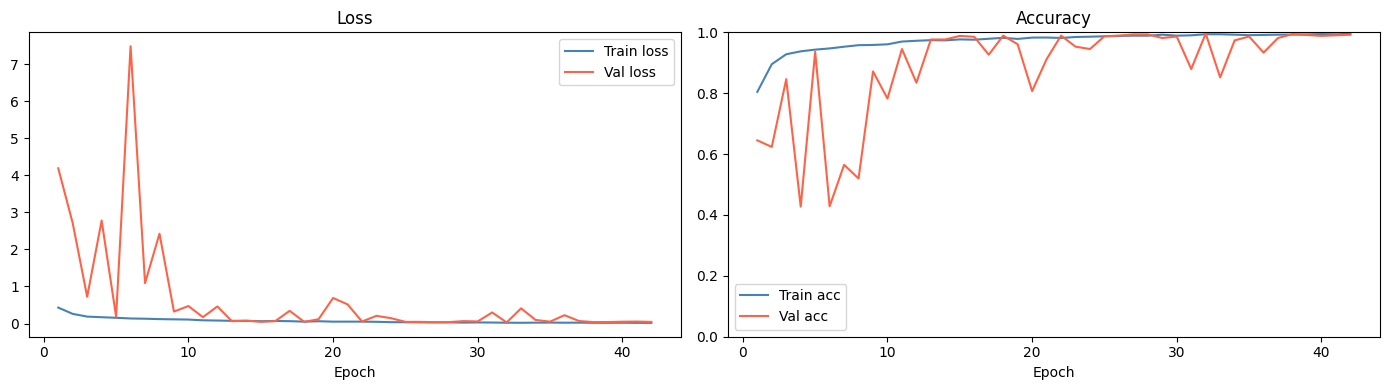

Best epoch: 32  |  Val accuracy: 0.9961


In [7]:
h = history.history
epochs_ran = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_ran, h['loss'],     label='Train loss', color='steelblue')
axes[0].plot(epochs_ran, h['val_loss'], label='Val loss',   color='tomato')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs_ran, h['accuracy'],     label='Train acc', color='steelblue')
axes[1].plot(epochs_ran, h['val_accuracy'], label='Val acc',   color='tomato')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].legend()

plt.tight_layout()
plt.show()

best_epoch = np.argmin(h['val_loss']) + 1
best_acc   = h['val_accuracy'][best_epoch - 1]
print(f'Best epoch: {best_epoch}  |  Val accuracy: {best_acc:.4f}')

## 7. Save model

In [8]:
clf.save(MODEL_PATH)
print(f'Model saved → {MODEL_PATH}')

Saved CNN model → ../models\cnn_model.keras
Model saved → ../models\cnn_model.keras
